# PURE Kinetics Analysis Tutorial

This tutorial walks through analyzing time-series data from plate reader experiments using the `cdk` platereader module. We'll cover loading data, picking the read you care about, plotting raw curves, normalizing to a standard, fitting kinetic parameters, and visualizing results.

The companion notebook `platereader.ipynb` runs the same code without the explanations — use it as a clean working template once you're comfortable with the steps here. We also describe more in depth on the kinetics analysis of plate reader experiments in a [kinetics DevNote](https://devnotes.nucleus.engineering/articles/Newman-20260421)

## Table of Contents
1. [Setup](#setup)
2. [Load Data](#load-data)
3. [Plot Raw Curves](#plot-curves)
4. [Normalize Data](#normalize)
5. [Kinetic Analysis](#kinetic-analysis)
6. [Summary Plots](#summary)


### Note for those that care about the code (ignore if not!)

The API is object-oriented. Two objects do almost all the work:

- **`PlateReaderResult`** — what loading returns. A list-like container of one or more *blocks*, one per read on the plate (e.g. two gains, or two ex/em spectra).
- **`PlateReaderData`** — a single block. It behaves like a DataFrame (you can index and slice it) but also carries methods that return *new* `PlateReaderData` objects: `.plot()`, `.normalize()`, `.blank()`, `.fit_kinetics()`, and more. Transforms are immutable and chainable.

Fitting kinetics returns a **`Kinetics`** object with its own `.summary`, `.plot()`, and `.plot_summary()`.

---

## 1. Setup

Import the necessary libraries and the `cdk` platereader module. We alias it to `pr`. Logging is set to `ERROR` to keep the notebook output clean.


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option('display.max_columns', None)

import seaborn as sns
import matplotlib.pyplot as plt

# Import the cdk platereader module
from cdk.instruments import platereader as pr

from cdk import logging
log = logging.setup_logging(logging.ERROR)

---

## 2. Load Data

Load your plate reader output and merge it with the platemap that describes your experimental conditions.

- `data_file`: path to your plate reader data. Current support is for **BioTek** outputs (absorbance, luminescence, fluorescence).
- `platemap_file`: path to a platemap CSV mapping each `Well` to its experimental conditions. See the [platemap tutorial](https://docs.nucleus.engineering/guides/platemap-tutorial/) for the expected format.
- `load_platereader_data()` parses the file, integrates the platemap, and returns a **`PlateReaderResult`** — a container of one block per read on the plate.


In [2]:
# Specify file paths
data_file = "sample-data/20251111-122213-cytation5-pure-timecourse-gfp-MFG-98-tRNA-QC.txt"
platemap_file = "sample-data/platemap.csv"

# Load data
result = pr.load_platereader_data(
    data_file=data_file,
    platemap_file=platemap_file,
    platereader="biotek" # options: "biotek"
)

The output is a `PlateReaderResult`: a list-like collection of `PlateReaderData` blocks. If you did more than one read on the plate (multiple gains, or different ex/em spectra), each read is a separate block. Print it to see what's inside:


In [3]:
print(result)

PlateReaderResult with the following 2 blocks:
0: (1533, 54) kinetic read with reads: GFP-G70:485,528 (Fluorescence) (Plate 'Plate 1')
1: (1533, 54) kinetic read with reads: GFP-Gext:485,528 (Fluorescence) (Plate 'Plate 1')


Here there were two reads with different gains but the same excitation/emission spectrum, on one plate. To work with a single read, index into the result to pull out that block. If we want the `GFP-Gext` read, that's block index `1`:


In [4]:
desired_index = 1
data = result[desired_index]

You can see the underlying data with `data.view()` (which returns a Pandas DataFrame):

In [5]:
data.view().head()

,Date,Experiment,Well,Name,Type,Time,Data,Read,Read Name,Reader Type,Reader ID,Plate Type,Plate ID,Start Time,Read Modality,Gain,Excitation Wavelength (nm),Excitation Bandwidth (nm),Excitation Optics,Emission Wavelength (nm),Emission Bandwidth (nm),Emission Optics,Read Geometry,Read Height (mm),PMix ID,[PMix] (mg/mL),Ribosome ID,[Ribosome] (uM),SMS ID,tRNA ID,[tRNA] (ug/uL),DNA ID,[DNA] (ng/uL),PMix Vol (uL),Ribosome Vol (uL),SMS Vol (uL),tRNA Vol (uL),DNA Vol (uL),RNase Inhib Vol (uL),Water vol (uL),Rxn Volume (uL)
0,2025-11-11,MFG-98-tRNA-QC,B2,tRNA AR-836,Sample,0 days 00:00:33,245,"GFP-Gext:485,528",GFP-Gext,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 1,2025-11-11 12:24:04,Fluorescence,extended,485,20,monochromator,528,20,monochromator,Top,10.5 mm,NEB Sol B,NaN,NaN,NaN,SMS-08,AR-836,35.0,AR-805,120.0,3.0,NaN,3.0,1.0,0.5,0.5,2.0,10.0
1,2025-11-11,MFG-98-tRNA-QC,B2,tRNA AR-836,Sample,0 days 00:05:33,254,"GFP-Gext:485,528",GFP-Gext,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 1,2025-11-11 12:24:04,Fluorescence,extended,485,20,monochromator,528,20,monochromator,Top,10.5 mm,NEB Sol B,NaN,NaN,NaN,SMS-08,AR-836,35.0,AR-805,120.0,3.0,NaN,3.0,1.0,0.5,0.5,2.0,10.0
2,2025-11-11,MFG-98-tRNA-QC,B2,tRNA AR-836,Sample,0 days 00:10:33,249,"GFP-Gext:485,528",GFP-Gext,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 1,2025-11-11 12:24:04,Fluorescence,extended,485,20,monochromator,528,20,monochromator,Top,10.5 mm,NEB Sol B,NaN,NaN,NaN,SMS-08,AR-836,35.0,AR-805,120.0,3.0,NaN,3.0,1.0,0.5,0.5,2.0,10.0
3,2025-11-11,MFG-98-tRNA-QC,B2,tRNA AR-836,Sample,0 days 00:15:33,230,"GFP-Gext:485,528",GFP-Gext,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 1,2025-11-11 12:24:04,Fluorescence,extended,485,20,monochromator,528,20,monochromator,Top,10.5 mm,NEB Sol B,NaN,NaN,NaN,SMS-08,AR-836,35.0,AR-805,120.0,3.0,NaN,3.0,1.0,0.5,0.5,2.0,10.0
4,2025-11-11,MFG-98-tRNA-QC,B2,tRNA AR-836,Sample,0 days 00:20:33,265,"GFP-Gext:485,528",GFP-Gext,Cytation5,1705168,Greiner 384 SV NoBind AutoMap,Plate 1,2025-11-11 12:24:04,Fluorescence,extended,485,20,monochromator,528,20,monochromator,Top,10.5 mm,NEB Sol B,NaN,NaN,NaN,SMS-08,AR-836,35.0,AR-805,120.0,3.0,NaN,3.0,1.0,0.5,0.5,2.0,10.0


---

## 3. Plot Raw Curves

First, visualize the data with `data.plot()`. The method is format-aware: for a kinetic (time-series) block it draws fluorescence over time, one line per well, colored by the `Name` column (your experimental condition).

Passing `style='Type'` uses different line styles for the different well types (samples, standards, blanks), which makes it easy to spot controls. This helps you catch outliers, failed reactions, or unexpected kinetics before fitting.


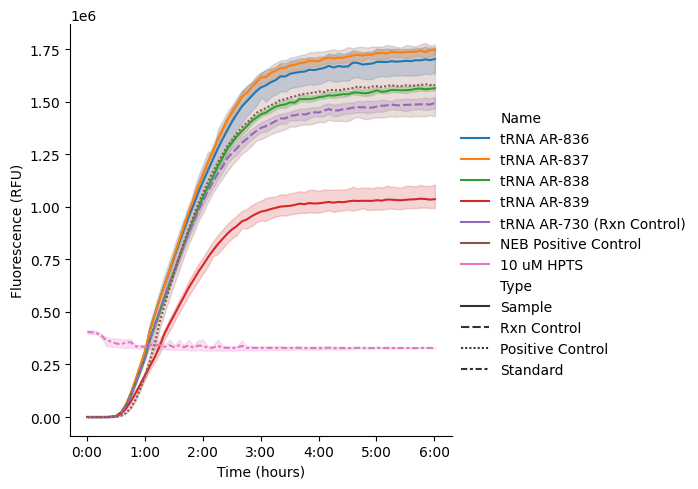

In [6]:
data.plot(style='Type')

We can see that the standard (here, HPTS) is stable and can be safely used for normalization.


---

## 4. Normalize Data

Normalize to an internal fluorescence standard so values are comparable across experiments and instruments. `data.normalize('<standard name>')` averages each well over a time window at the end of the run (1 hour by default), then divides all data by the mean of that window-average across every well sharing the same `Name` as the standard.

The standard's name must match the `Name` column from your platemap. To check the exact name:


In [7]:
# To check the exact name of your standard
platemap = data.platemap
standards = platemap[platemap['Type']=='Standard']
standards['Name'].unique()

array(['10 uM HPTS'], dtype=object)

In [8]:
data = data.normalize('10 uM HPTS')

Now replot your curves to see them normalized. We exclude the standard from the plot since it's now flat at ~1:

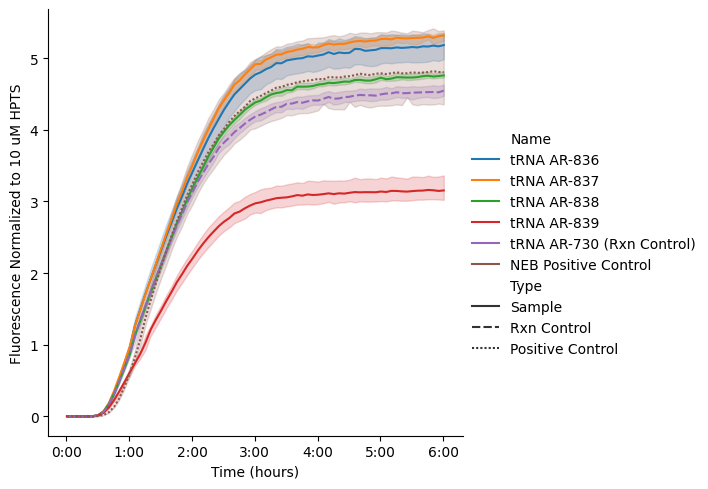

In [9]:
g = data.plot(style='Type', exclude_types=['Standard'])
# g.savefig('after-normalization.png',dpi=300)

If you want to change the time window over which the end-of-run average is calculated, pass the `window` argument:

In [10]:
# data = data.normalize('10 uM HPTS', window=pd.Timedelta("2.5h"))

---

## 5. Kinetic Analysis

See the [DevNote](https://devnotes.nucleus.engineering/articles/Newman-20260421) on kinetic analysis for more details.

`data.fit_kinetics()` fits a **sigmoid-with-drift** curve to each well (grouped by unique well identifiers: `Experiment`, `Well`, `Read`, and `Reader ID` by default) and extracts interpretable kinetic parameters.

The model:

$$y(t) = \frac{L}{1 + e^{-k(t - \tau_{vmax})}} + b\,(t - \tau_{drift})$$

- $L$: steady-state level (asymptote)
- $k$: growth rate (steepness)
- $\tau_{vmax}$: inflection point (time of maximum velocity)
- $b$: drift rate (linear signal change after steady-state)
- $\tau_{drift}$: drift onset time

See the [DevNote](https://devnotes.nucleus.engineering/articles/Newman-20260421) on kinetic analysis for more details.

**Metrics extracted:**

  - **Maximum velocity**: maximum rate of fluorescence increase (slope at inflection point)
  - **Lag time**: time to reach the exponential phase
  - **Steady-state**: final fluorescence level
  - **Time-to-completion**: time to reach 95% of the asymptote
  - **Drift**: rate of signal decay or increase after steady-state
  - **R²**: goodness of fit; "Good Fit" is `True` if $R^2 \geq 0.95$


In [11]:
# Perform kinetic analysis using sigmoid_drift model
kinetics = data.fit_kinetics()

[07/16/26 17:26:37] INFO     Calculating Kinetics                analysis.py:223


`fit_kinetics()` returns a `Kinetics` object. Its `.summary` property is a tidy table of the fitted parameters and quality metrics per group (all-null columns dropped):


In [12]:
kinetics.summary

,Well,Name,Max Velocity,Max Velocity Time,Lag Time,Steady State,Completion Time,Completion Threshold,Drift,Fit Function,R^2,Good Fit,Normalized to
0,B2,tRNA AR-836,2.49,0 days 01:33:15,0 days 00:33:09,4.74,0 days 03:01:44,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
1,B4,tRNA AR-837,2.67,0 days 01:33:35,0 days 00:34:38,4.99,0 days 03:00:24,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
2,B6,tRNA AR-838,2.44,0 days 01:32:35,0 days 00:34:21,4.50,0 days 02:58:17,0.95,0.06,sigmoid_drift,1.00,True,10 uM HPTS
3,B8,tRNA AR-839,1.68,0 days 01:32:00,0 days 00:37:35,2.89,0 days 02:52:07,0.95,0.03,sigmoid_drift,1.00,True,10 uM HPTS
4,B10,tRNA AR-730 (Rxn Control),2.37,0 days 01:30:01,0 days 00:33:50,4.22,0 days 02:52:45,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
5,B12,NEB Positive Control,2.66,0 days 01:35:50,0 days 00:45:09,4.27,0 days 02:50:26,0.95,0.09,sigmoid_drift,1.00,True,10 uM HPTS
6,D2,tRNA AR-836,2.64,0 days 01:31:44,0 days 00:32:12,4.97,0 days 02:59:23,0.95,0.08,sigmoid_drift,1.00,True,10 uM HPTS
7,D4,tRNA AR-837,2.79,0 days 01:32:13,0 days 00:34:27,5.10,0 days 02:57:16,0.95,0.07,sigmoid_drift,1.00,True,10 uM HPTS
8,D6,tRNA AR-838,2.52,0 days 01:32:00,0 days 00:34:31,4.58,0 days 02:56:37,0.95,0.06,sigmoid_drift,1.00,True,10 uM HPTS
9,D8,tRNA AR-839,1.84,0 days 01:30:32,0 days 00:35:41,3.20,0 days 02:51:17,0.95,0.04,sigmoid_drift,1.00,True,10 uM HPTS


## Visualize Fits on Individual Wells

`kinetics.plot()` overlays each fitted curve on its raw data so you can confirm the fits are reasonable (high R², smooth curves). Faceting by `Well` shows one panel per well:


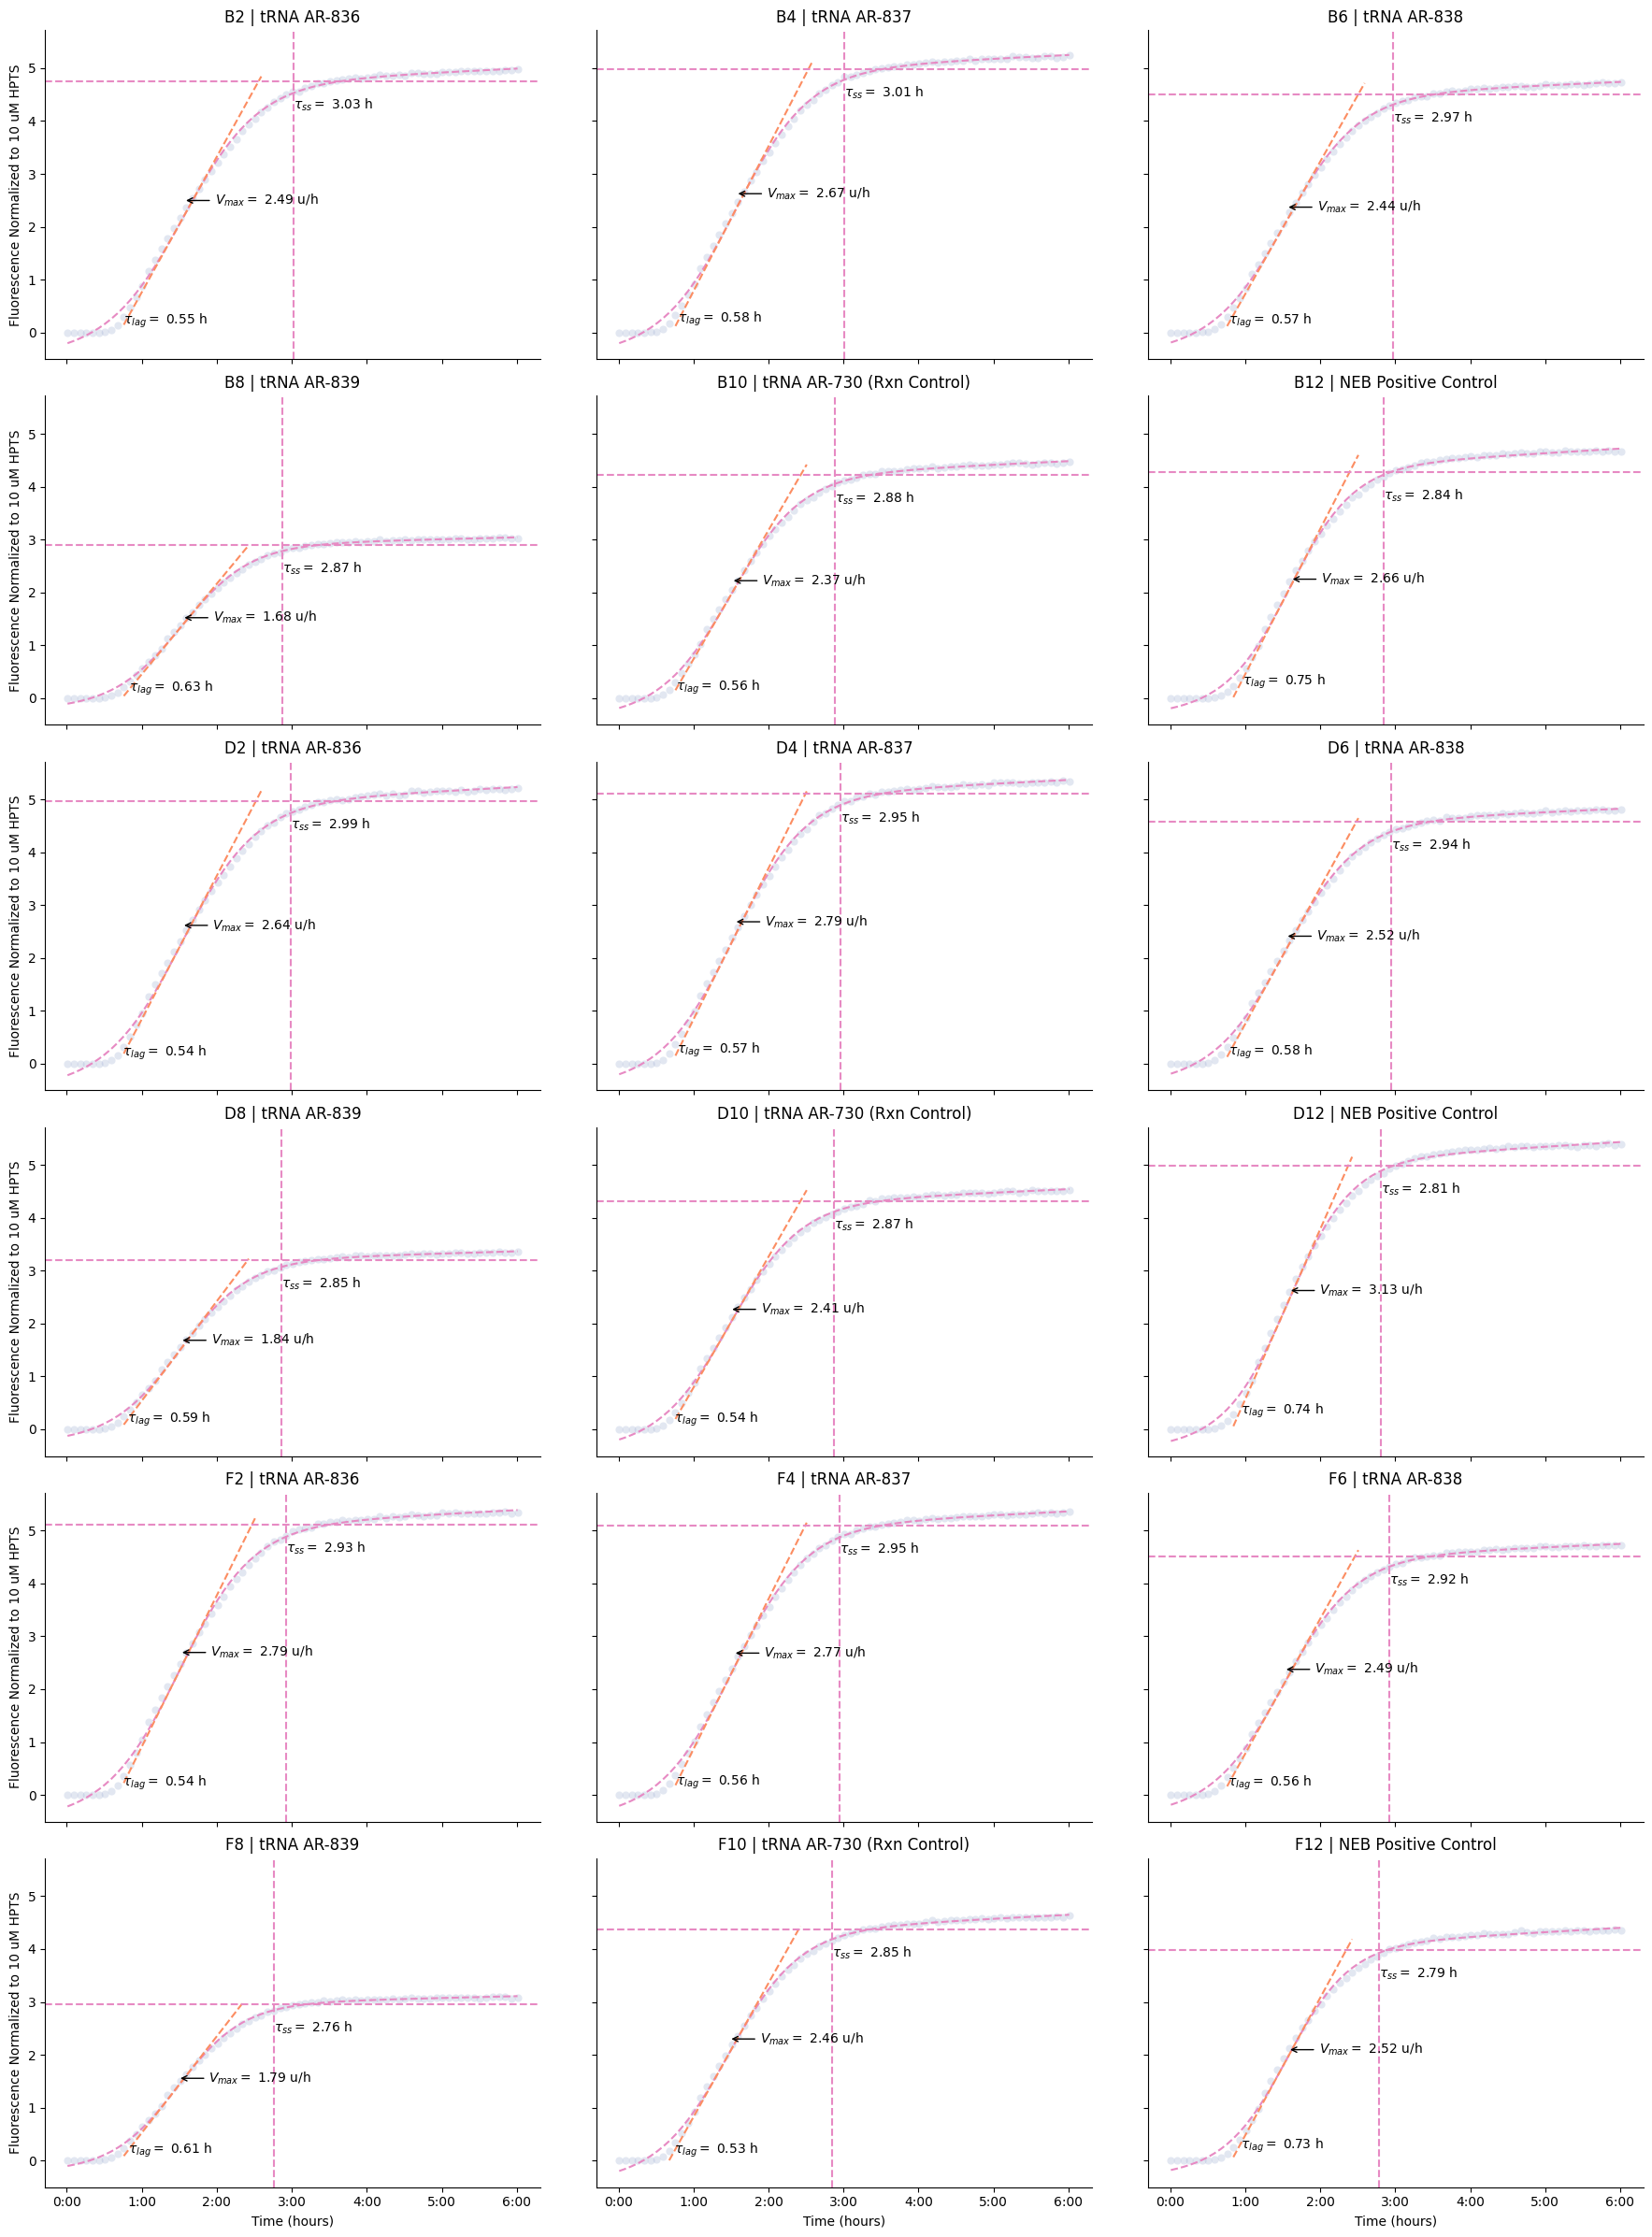

In [13]:
g = kinetics.plot(col="Well")

## Or, visualize across replicates:

Called with no `col` argument, `kinetics.plot()` facets by `Name` instead, overlaying replicate wells of each condition in a single panel:


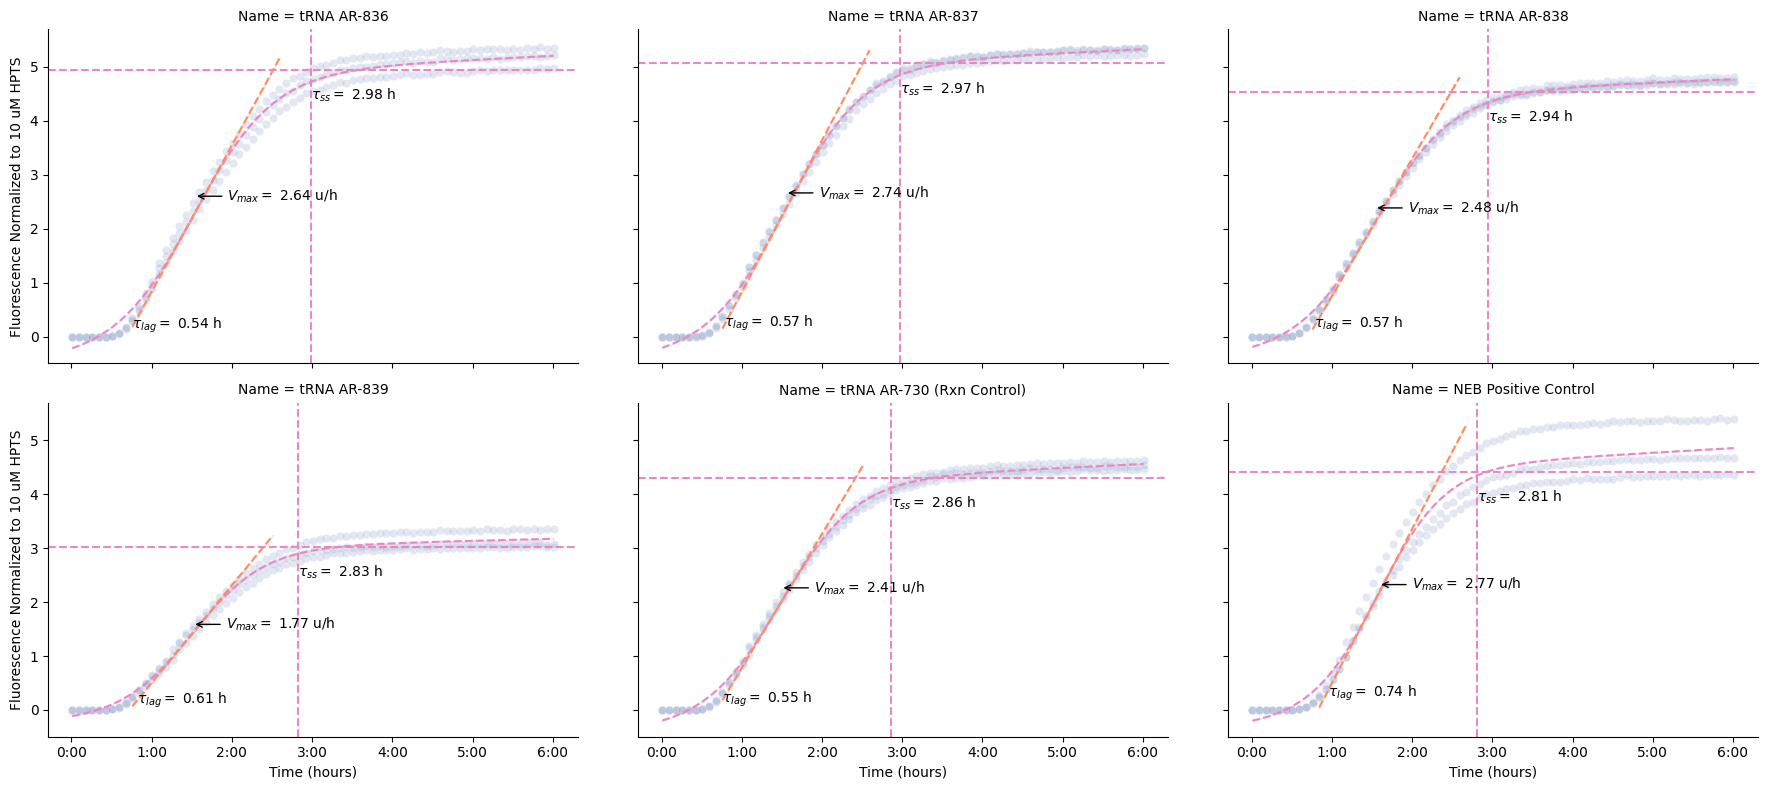

In [14]:
kinetics.plot()

---

## 6. Summary Plots

`kinetics.plot_summary()` produces a multi-panel figure comparing kinetic parameters across conditions: per-experiment time series alongside bar plots of steady-state, max velocity, and drift, with error bars across technical replicates.

Extra keyword arguments (`experiment_split`, `ys_to_plot`, `plot_time_series`) are forwarded to the underlying plotter if you want to plot only a subset — for example:

```python
g = kinetics.plot_summary(ys_to_plot=["Max Velocity"], plot_time_series=True)
g.savefig("data_summary.png", dpi=300)
```


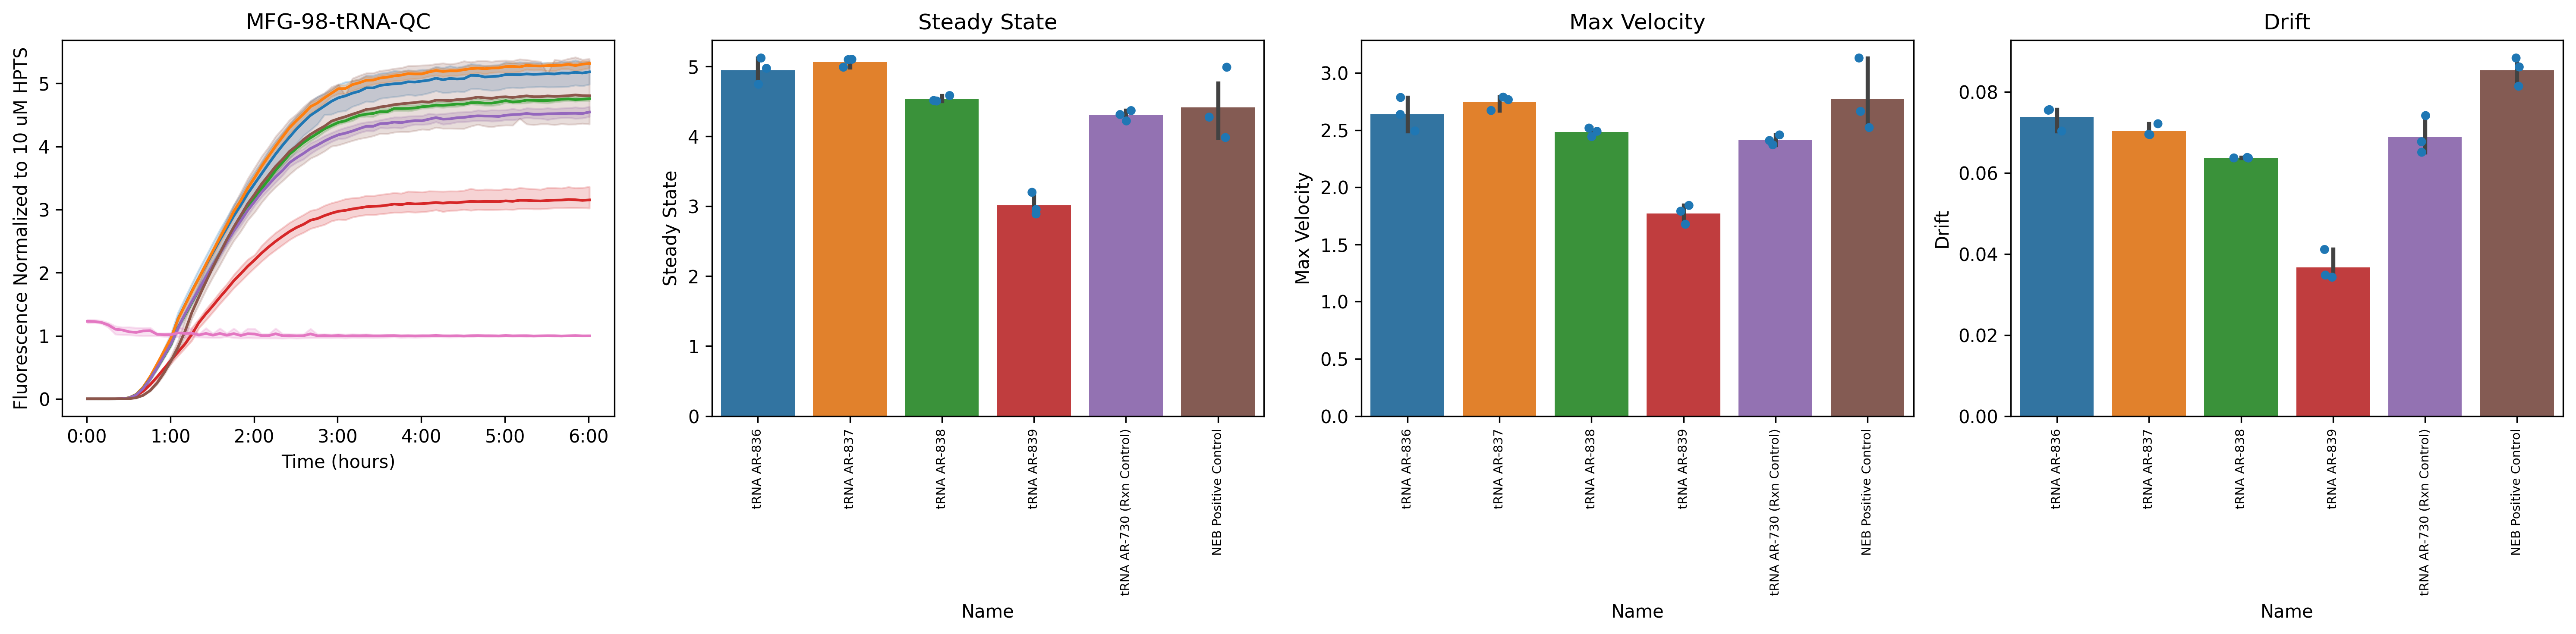

In [15]:
g = kinetics.plot_summary()

---

## Key Metrics Explained

### 1. **Steady-State Level** (`Steady State, Data`)
- The final fluorescence value reached by the reaction
- Represents the total amount of protein produced
- Higher values indicate greater expression yield

### 2. **Maximum Velocity** (`Velocity, Max`)
- The steepest slope of the fluorescence curve (at the inflection point)
- Units: RFU per second
- Reflects the peak rate of protein synthesis
- Sensitive to enzyme activity, substrate availability, and reaction conditions

### 3. **Lag Time** (`Lag, Time`)
- Time before exponential fluorescence increase begins
- May reflect time for ribosome assembly or initial translation steps
- Shorter lag times suggest faster reaction initiation

### 4. **Drift** (`Fit, drift`)
- Rate of fluorescence change after reaching steady-state
- Positive drift: continued synthesis or aggregation
- Negative drift: photobleaching, protein degradation, or quenching
- Units: RFU per second

### 5. **R² Value** (`Fit, R^2`)
- Goodness of fit (0 to 1, higher is better)
- R² > 0.98 indicates excellent fit
- Poor fits may indicate noisy data, overflow errors, or non-sigmoid kinetics


---

## Tips and Troubleshooting

- **Overflow errors:** Wells with `OVRFLW` or `NaN` values are automatically excluded from fitting
- **Poor fits (low R²):** Inspect raw curves for anomalies (bubbles, evaporation, pipetting errors)
- **Drift:** Sometimes seen in kinetics curves; the default `sigmoid_drift` model accounts for it
- **Multiple replicates:** Always include technical replicates and report error bars
- **Comparing conditions:** Normalize or blank data consistently across all samples
